In [82]:
#installed and imported packages
!pip install flaml
from flaml import AutoML
import pandas as pd
import numpy as np
from sklearn.model_selection import *
from sklearn.preprocessing import *
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from flaml import tune
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.utils import resample

In [83]:
#Read in file and examined features
df = pd.read_csv('/content/drive/MyDrive/llm_aware_evaluation_dataset.csv')
df.head()

,timestamp,user_id,group_id,city,device,x1,x2,x3,x4,x5,hv_noise,amount,num_prev_events,sensor_quality,leaky_proxy,post_event_signal,future_agg_hint,weekend,hour,y
0,2025-12-04 21:19:02,2420,121,city_05,mobile,-1.589853,-0.284299,1.269684,1.524103,-1.003742,-1.088536,24.776058,3,0.814312,1.491166,-0.410987,0.017026,0,21,0
1,2025-09-19 06:27:05,607,288,city_06,web,0.080811,-2.247639,0.132110,1.472092,-0.505903,5.200460,60.881373,4,0.578583,-0.445110,-0.416453,-0.599166,0,6,0
2,2025-11-17 05:23:34,2492,60,city_08,mobile,2.265833,1.908551,-1.693229,-0.880005,0.891976,0.789286,128.140130,4,0.660433,-0.017534,0.185209,-0.696157,0,5,0
3,2025-09-10 16:18:24,2366,341,city_09,mobile,-1.263784,-0.844188,-1.825877,-1.669408,1.295034,-3.966892,10.351440,3,0.864142,1.385089,1.618444,0.195618,0,16,1
4,2026-01-03 06:07:47,2028,156,city_03,web,0.055249,0.295087,-0.616812,0.676810,0.136157,-6.107795,22.279520,2,0.867008,-0.762453,-0.158619,1.184206,1,6,0


<Axes: title={'center': 'Adverse Events Frequency'}, ylabel='y'>

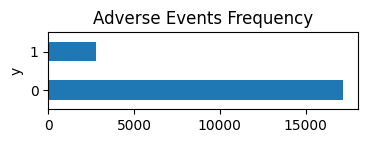

In [84]:
#Visualised frequency of events
df['y'].value_counts().plot(kind = 'barh', figsize = (4, 1), title = 'Adverse Events Frequency')

In [85]:
#Dropped leaky cols and identifiers
to_drop = ['leaky_proxy', 'future_agg_hint', 'post_event_signal', 'user_id', 'group_id']  # list all columns to drop
df = df.drop(columns=to_drop)


In [86]:
#Split data temporally

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
n = len(df)
train_size = int(0.6 * n)
val_size = int(0.8 * n)

train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:val_size]
test_df  = df.iloc[val_size:]

X_train = train_df.drop(columns=['timestamp', 'y'])
X_val   = val_df.drop(columns=['timestamp', 'y'])
X_test  = test_df.drop(columns=['timestamp', 'y'])

y_train = train_df['y']
y_val  = val_df['y']
y_test  = test_df['y']

In [87]:
#One hot encoded categorical data
cat_names = ['city', 'device']
cat_cols = X_train[cat_names]

ohe_encoder = OneHotEncoder(drop = 'first', sparse_output = False).set_output(transform = 'pandas')

train_cat_encoded = ohe_encoder.fit_transform(X_train[cat_names])
val_cat_encoded = ohe_encoder.transform(X_val[cat_names])
test_cat_encoded = ohe_encoder.transform(X_test[cat_names])

X_train = pd.concat([X_train.drop(columns=cat_names), train_cat_encoded], axis=1)
X_val = pd.concat([X_val.drop(columns=cat_names), val_cat_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_names), test_cat_encoded], axis=1)

In [88]:
#Standardised numerical data
to_scale = ['x1', 'x2', 'x3', 'x4', 'x5', 'hv_noise', 'amount', 'num_prev_events', 'sensor_quality', 'hour']

scaler = StandardScaler().set_output(transform="pandas")
scaler.fit(X_train[to_scale])

X_train[to_scale] = scaler.transform(X_train[to_scale])
X_val[to_scale]   = scaler.transform(X_val[to_scale])
X_test[to_scale]  = scaler.transform(X_test[to_scale])

In [89]:
#Trained baseline lr model

lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)

y_pred_LR = lr_model.predict(X_test)

y_probs_LR = lr_model.predict_proba(X_test)[:, 1]

print('Evaluation on Testing Set\n', classification_report(y_test, y_pred_LR))
print('Confusion matrix\n',confusion_matrix(y_test, y_pred_LR))
print(f"ROC AUC: {roc_auc_score(y_test, y_probs_LR):.4f}")
print(f"PR AUC:  {average_precision_score(y_test, y_probs_LR):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_probs_LR):.4f}")

Evaluation on Testing Set
               precision    recall  f1-score   support

           0       0.96      0.97      0.96      3788
           1       0.31      0.26      0.28       212

    accuracy                           0.93      4000
   macro avg       0.63      0.61      0.62      4000
weighted avg       0.92      0.93      0.93      4000

Confusion matrix
 [[3663  125]
 [ 157   55]]
ROC AUC: 0.7609
PR AUC:  0.2091
Brier Score: 0.0712


In [90]:
#Computed PR-AUC CI for baseline

n_iterations = 1000
bootstrapped_scores = []

y_test_arr = np.array(y_test)
y_probs_arr = np.array(y_probs_LR)

for i in range(n_iterations):
    indices = resample(np.arange(len(y_test_arr)), replace=True)
    score = average_precision_score(y_test_arr[indices], y_probs_arr[indices])
    bootstrapped_scores.append(score)

lower = np.percentile(bootstrapped_scores, 2.5)
upper = np.percentile(bootstrapped_scores, 97.5)

print(f"95% Confidence Interval for PR-AUC: [{lower:.4f} to {upper:.4f}]")

95% Confidence Interval for PR-AUC: [0.1662 to 0.2701]


In [91]:
#Designed automl custom params

pos_rate = float(y_train.mean())
scale_pos_weight = float((1 - pos_rate) / pos_rate)

custom_params = {
    "xgboost": {
        "scale_pos_weight": {
            "domain": tune.uniform(lower=scale_pos_weight*0.8, upper=scale_pos_weight*1.5),
        },
        "max_depth": {
            "domain": tune.randint(lower=1, upper=10),
        },
        "n_estimators": {
            "domain": tune.randint(lower=20, upper=500),
        }
    },

    "lgbm": {
        "scale_pos_weight": {
            "domain": tune.uniform(lower=scale_pos_weight*0.8, upper=scale_pos_weight*1.5),
        },
        "max_depth": {
            "domain": tune.randint(lower=1, upper=10),
        },
        "n_estimators": {
            "domain": tune.randint(lower=20, upper=500),
        }
    }
}

In [92]:
#Fitted automl model
model_config = {
    'task'          : 'classification',
    'time_budget'   : 60,
    'metric'        : 'ap',
    'eval_method'   : 'holdout',
    'verbose'       : 0,
    'custom_hp'     : custom_params,
    'estimator_list': ['xgboost', 'lgbm'],
    'seed'          : 42,
}
model = AutoML()
model.fit(X_train = X_train,
          y_train = y_train,
          X_val = X_val,
          y_val = y_val,
          **model_config)

In [93]:
#Got results from automl model
from sklearn.metrics import brier_score_loss

y_pred = model.predict(X_test)

y_probs = model.predict_proba(X_test)[:, 1]

print('Evaluation on Testing Set\n', classification_report(y_test, y_pred))
print('Confusion matrix\n',confusion_matrix(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_probs):.4f}")
print(f"PR AUC:  {average_precision_score(y_test, y_probs):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_probs):.4f}")

Evaluation on Testing Set
               precision    recall  f1-score   support

           0       0.98      0.56      0.72      3788
           1       0.09      0.82      0.17       212

    accuracy                           0.58      4000
   macro avg       0.54      0.69      0.44      4000
weighted avg       0.94      0.58      0.69      4000

Confusion matrix
 [[2138 1650]
 [  39  173]]
ROC AUC: 0.7768
PR AUC:  0.2096
Brier Score: 0.2572


In [ ]:
#Computed PR-AUC CI for automl

n_iterations = 1000
bootstrapped_scores = []

y_test_arr = np.array(y_test)
y_probs_arr = np.array(y_probs)

for i in range(n_iterations):
    indices = resample(np.arange(len(y_test_arr)), replace=True)
    score = average_precision_score(y_test_arr[indices], y_probs_arr[indices])
    bootstrapped_scores.append(score)

lower = np.percentile(bootstrapped_scores, 2.5)
upper = np.percentile(bootstrapped_scores, 97.5)

print(f"95% Confidence Interval for PR-AUC: [{lower:.4f} to {upper:.4f}]")

In [ ]:
#Printed automl selected model
print(model.model)

In [ ]:
#Conducted McNemar's test for two models

lr_correct = (y_pred_LR == y_test)
gb_correct = (y_pred == y_test)

table = np.zeros((2, 2))
table[0, 0] = np.sum(lr_correct & gb_correct)
table[0, 1] = np.sum(lr_correct & ~gb_correct)
table[1, 0] = np.sum(~lr_correct & gb_correct)
table[1, 1] = np.sum(~lr_correct & ~gb_correct)

result = mcnemar(table, exact=False, correction=True)

print(f"McNemar's Statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("Result: Statistically Significant. The models perform differently.")
else:
    print("Result: Not Significant. No evidence that one model is statistically 'better' than the other.")